# Нейронная сеть Хопфилда для прогнозирования финансовых показателей

**Задание №4:**
- **Вход НС:** Некоторый набор финансовых показателей (курсы акций, валют, цены на сырьё).
- **На выходе НС:** Предсказание на **L** шагов вперёд одного из показателей.
- **Изменяемые параметры:** `M` — ширина окна наблюдения, `D` — глубина задержек, `Ns` — число элементов в скрытом слое.

**Архитектура:** Classical Hopfield Network (непрерывная версия) реализована через TensorFlow/Keras.  
Сеть Хопфилда используется как ассоциативная память: окно исторических цен кодируется в «паттерн», а слой Хопфилда извлекает из обученной памяти наиболее близкое состояние, которое затем декодируется в прогноз.

---
**Параметры сети:**
| Параметр | Описание |
|----------|----------|
| `M` | Ширина окна наблюдения (кол-во дней в истории) |
| `D` | Глубина задержек (шаг дискретизации внутри окна) |
| `L` | Горизонт прогнозирования (кол-во дней вперёд) |
| `Ns` | Число нейронов в скрытом/ассоциативном слое |

## 1. Импорт библиотек и настройка GPU

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# ── Настройка GPU (NVIDIA) ──────────────────────────────────────────────────
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"✓ Найдено GPU: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Память GPU будет выделяться по мере необходимости (memory growth)")
    except RuntimeError as e:
        print(f"⚠ Ошибка настройки памяти: {e}")
    tf.config.set_visible_devices(gpus[0], "GPU")
    print(f"✓ Активный GPU: {gpus[0].name}")
else:
    print("⚠ GPU не найдено, используется CPU")

print(f"\nTensorFlow версия: {tf.__version__}")
print(f'Используемое устройство: {"GPU" if gpus else "CPU"}')

✓ Найдено GPU: 1
  GPU 0: /physical_device:GPU:0
✓ Память GPU будет выделяться по мере необходимости (memory growth)
✓ Активный GPU: /physical_device:GPU:0

TensorFlow версия: 2.20.0
Используемое устройство: GPU


## 2. Гиперпараметры эксперимента

In [18]:
# ── Базовые параметры (фиксируются при варьировании одного из параметров) ──
M = 30  # Ширина окна наблюдения (дней)
D = 1  # Глубина задержек (шаг выборки внутри окна)
L = 5  # Горизонт прогнозирования (дней вперёд)
Ns = 128  # Число нейронов в скрытом (ассоциативном) слое Хопфилда
BETA = 1.0  # Температурный параметр softmax в сети Хопфилда
EPOCHS = 60  # Эпохи обучения
BATCH = 32  # Размер мини-батча

print("Параметры эксперимента:")
print(f"  M  = {M}  (ширина окна)")
print(f"  D  = {D}  (глубина задержек)")
print(f"  L  = {L}  (горизонт прогноза)")
print(f"  Ns = {Ns} (нейронов в слое Хопфилда)")
print(f"  β  = {BETA} (температура)")

Параметры эксперимента:
  M  = 30  (ширина окна)
  D  = 1  (глубина задержек)
  L  = 5  (горизонт прогноза)
  Ns = 128 (нейронов в слое Хопфилда)
  β  = 1.0 (температура)


## 3. Загрузка финансовых данных

Используем котировки золота (GC=F) как основной прогнозируемый показатель.

Загружено строк: 1577


,gold,silver
Date,,
2020-01-02,1524.500000,17.966000
2020-01-03,1549.199951,18.068001
2020-01-06,1566.199951,18.097000
2020-01-07,1571.800049,18.316000
2020-01-08,1557.400024,18.087999


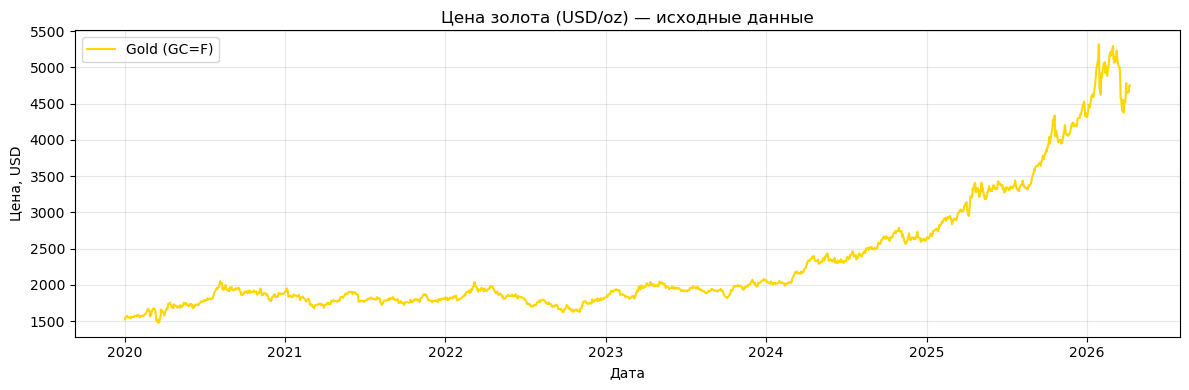

In [19]:
tickers = ["GC=F", "SI=F"]
raw = yf.download(tickers, start="2020-01-01", progress=False)

gold = raw["Close"]["GC=F"]
silver = raw["Close"]["SI=F"]

data = pd.DataFrame({"gold": gold, "silver": silver}).dropna()
print(f"Загружено строк: {len(data)}")
display(data.head())

plt.figure(figsize=(12, 4))
plt.plot(data.index, data["gold"], label="Gold (GC=F)", color="gold")
plt.title("Цена золота (USD/oz) — исходные данные")
plt.xlabel("Дата")
plt.ylabel("Цена, USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Предобработка данных

Нормализация + формирование скользящих окон с параметрами M, D, L.

In [20]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[["gold"]])


def build_dataset(series, M, D, L):
    """Формирует пары (X, y): X — скользящее окно, y — значение через L шагов.

    Args:
        series: нормализованный массив цен (ожидается 2D или 1D)
        M: ширина окна наблюдения (временной интервал)
        D: шаг задержки (стрейд)
        L: горизонт прогнозирования
    """
    X, y = [], []
    n = len(series)

    # Убедимся, что series — numpy массив для корректной индексации
    if not isinstance(series, np.ndarray):
        series = np.array(series)

    for i in range(M, n - L):

        start_idx = i - M
        indices = list(range(start_idx, i, D))

        # Проверка на случай, если indices пуст (защита от ошибок при больших D)
        if not indices:
            continue

        window = series[indices].flatten()

        # Обработка target в зависимости от размерности series
        if series.ndim == 1:
            target = series[i + L]
        else:
            target = series[i + L, 0]

        X.append(window)
        y.append(target)

    # Теперь все элементы в X имеют одинаковую длину, ошибка исчезнет
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X, y = build_dataset(data_scaled, M, D, L)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Обучающая выборка:  {X_train.shape[0]} образцов, признаков: {X_train.shape[1]}")
print(f"Тестовая выборка:   {X_test.shape[0]} образцов")

Обучающая выборка:  1233 образцов, признаков: 30
Тестовая выборка:   309 образцов


## 5. Архитектура: Classic Hopfield Network

### Теоретическая база

**Классическая сеть Хопфилда** (Hopfield, 1982) — это рекуррентная сеть с симметричными весами, используемая как ассоциативная память. Энергетическая функция:

$$E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j$$

**Classical Hopfield Networks** (Ramsauer et al., 2020) — непрерывная версия с экспоненциальной ёмкостью памяти. Правило обновления состояния:

$$\mathbf{x}^{\text{new}} = X^T \cdot \text{softmax}(\beta \cdot X \cdot \mathbf{x})$$

где $X$ — матрица хранимых паттернов, $\beta$ — обратная температура.

**Ключевое свойство:** один шаг Classical Hopfield = механизм **cross-attention** (как в трансформерах), что позволяет нативно интегрировать его в Keras как Custom Layer.

**Схема модели для прогнозирования:**
```
Вход [batch, n_features]
  → Dense (Encoder) [batch, Ns]          # Кодирование запроса
  → HopfieldLayer (Ассоциативная память) # Извлечение из памяти
  → Dense (Decoder) [batch, 1]           # Декодирование прогноза
```

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, Model


# --- Вспомогательная функция для градиента (STE) ---
@tf.custom_gradient
def sign_with_ste(x):
    """
    Функция sign с Straight-Through Estimator для обучения.
    Forward: возвращает -1 или 1
    Backward: пропускает градиент как есть (как identity)
    """

    def grad(dy):
        return dy  # Пропускаем градиент без изменений

    return tf.sign(x), grad


class ClassicalHopfieldLayer(layers.Layer):
    """Classical Hopfield Layer (1982) — дискретная ассоциативная память.

    Реализует рекуррентное обновление состояния классической сети Хопфилда:
        s_new = sign(W · s_old)

    Особенности реализации:
    - Использует симметричную матрицу весов W [dim, dim]
    - Требует нескольких итераций для сходимости
    - Нейроны имеют бинарные состояния (-1, +1) через функцию sign
    - Использует STE (Straight-Through Estimator) для возможности backprop

    Параметры:
        num_neurons:    число нейронов в сети (размерность состояния)
        num_iterations: число шагов обновления для сходимости
    """

    def __init__(self, num_neurons: int, num_iterations: int = 5, **kwargs):
        super().__init__(**kwargs)
        self.num_neurons = num_neurons
        self.num_iterations = num_iterations

    def build(self, input_shape):
        # Симметричная матрица весов W [num_neurons, num_neurons]
        # w_ij = w_ji, диагональ = 0 (нейрон не связан сам с собой)
        self.W = self.add_weight(
            name="weight_matrix",
            shape=(self.num_neurons, self.num_neurons),
            initializer="glorot_uniform",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        """
        inputs: [batch, num_neurons] — начальное состояние сети
        Returns: [batch, num_neurons] — состояние после итераций (бинарное)
        """
        state = inputs

        # Рекуррентное обновление состояния
        for _ in range(self.num_iterations):
            # h = W · s
            h = tf.matmul(state, self.W)
            # s_new = sign(h) с STE для обучения
            state = sign_with_ste(h)

        return state

    def store_patterns(self, patterns):
        """
        Записывает паттерны в память по правилу Хебба.
        W = Σ (ξ · ξ^T) / N

        Args:
            patterns: [num_patterns, num_neurons] — эталонные векторы (-1, +1)
        """
        if not self.built:
            self.build(input_shape=(None, patterns.shape[-1]))
        patterns = tf.cast(patterns, tf.float32)
        num_patterns = tf.shape(patterns)[0]

        # Правило Хебба: W = (1/N) * Σ ξ ξ^T
        W_hebb = tf.matmul(patterns, patterns, transpose_a=True) / tf.cast(
            num_patterns, tf.float32
        )

        # Обнуляем диагональ (нейроны не связаны сами с собой)
        mask = 1.0 - tf.eye(self.num_neurons)
        W_hebb = W_hebb * mask

        # Присваиваем веса
        self.W.assign(W_hebb)

    def get_config(self):
        cfg = super().get_config()
        cfg.update(
            {"num_neurons": self.num_neurons, "num_iterations": self.num_iterations}
        )
        return cfg


def build_hopfield_model(
    n_features: int, Ns: int = 128, num_iterations: int = 5
) -> Model:
    """Строит модель на основе Classical Hopfield Network.

    Args:
        n_features:      размерность входного вектора
        Ns:              число нейронов в слое Хопфилда
        num_iterations:  число шагов обновления
    Returns:
        Скомпилированная Keras-модель
    """
    inp = layers.Input(shape=(n_features,), name="input")

    # Encoder: проецируем вход в пространство состояний Хопфилда
    # Выход encoder должен быть в диапазоне [-1, 1] для корректной работы sign
    encoded = layers.Dense(Ns, activation="tanh", name="encoder")(inp)

    # Classical Hopfield Layer: рекуррентное обновление до сходимости
    hopf = ClassicalHopfieldLayer(
        num_neurons=Ns, num_iterations=num_iterations, name="hopfield_classical"
    )(encoded)

    # Residual connection + нормализация
    merged = layers.Add(name="residual")([encoded, hopf])
    normed = layers.LayerNormalization(name="layer_norm")(merged)

    # Decoder: прогноз
    out = layers.Dense(1, activation="linear", name="output")(normed)

    model = Model(inputs=inp, outputs=out, name="ClassicalHopfieldNet")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


# Демонстрация архитектуры с базовыми параметрами
demo_model = build_hopfield_model(n_features=X_train.shape[1], Ns=Ns)
demo_model.summary()

Model: "ClassicalHopfieldNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (Dense)     │ (None, 128)       │      3,968 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hopfield_classical  │ (None, 128)       │     16,384 │ encoder[0][0]     │
│ (ClassicalHopfield… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 128)       │          0 │ encoder[0][0],    │
│                     │                   │            │ hopfield_classic… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 128)       │        256 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ layer_norm[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,737 (81.00 KB)

 Trainable params: 20,737 (81.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Базовое обучение модели

Epoch 1/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.7319 - mae: 0.6492 - val_loss: 0.4802 - val_mae: 0.6416
Epoch 2/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0599 - mae: 0.1814 - val_loss: 0.2573 - val_mae: 0.4583
Epoch 3/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0083 - mae: 0.0687 - val_loss: 0.1722 - val_mae: 0.3576
Epoch 4/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0506 - mae: 0.1850 - val_loss: 0.2324 - val_mae: 0.4504
Epoch 5/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0341 - mae: 0.1268 - val_loss: 0.1113 - val_mae: 0.2929
Epoch 6/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022 - mae: 0.0354 - val_loss: 0.1189 - val_mae: 0.3061
Epoch 7/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - mae: 0.0301 - val_loss: 0.1139 - val_mae: 0.2854
Epoch 8/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - mae: 0.0384 - val_loss: 0.1229 - val_mae: 0.3167
Epoch 9/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - mae:

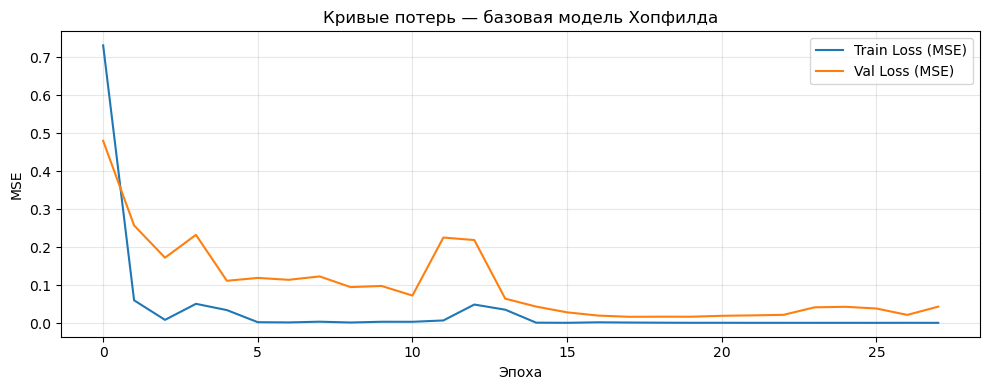

In [22]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=60,
    batch_size=32,
    early_stop=True,
    patience=10,
    verbose=0,
):
    """Обучение модели с опциональным EarlyStopping."""
    callbacks = []
    if early_stop:
        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True,
                verbose=0,
            )
        )
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )
    return history


with tf.device("/GPU:0" if gpus else "/CPU:0"):
    base_model = build_hopfield_model(X_train.shape[1], Ns=Ns)
    base_history = train_model(
        base_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=EPOCHS,
        batch_size=BATCH,
        early_stop=True,
        verbose=1,
    )

train_loss = base_history.history["loss"]
val_loss = base_history.history["val_loss"]
print(f"\nЛучший val_loss: {min(val_loss):.6f}")

# ── График кривых обучения ──────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_loss, label="Train Loss (MSE)")
plt.plot(val_loss, label="Val Loss (MSE)")
plt.title("Кривые потерь — базовая модель Хопфилда")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6а. Анализ матрицы паттернов Хопфилда

Матрица `stored_patterns` (W) — это «память» сети. Каждая строка — один запомненный вектор.
Посмотрим насколько сильно паттерны отличаются друг от друга и визуализируем структуру памяти.

**В теории:** здоровая память — паттерны хорошо разделены (расстояния большие).
Больная память — паттерны слипаются (малые расстояния), сеть путает одни воспоминания с другими.

Размер матрицы весов W: (128, 128)
  min=-0.2336  max=0.2288  mean=-0.0011  std=0.0989


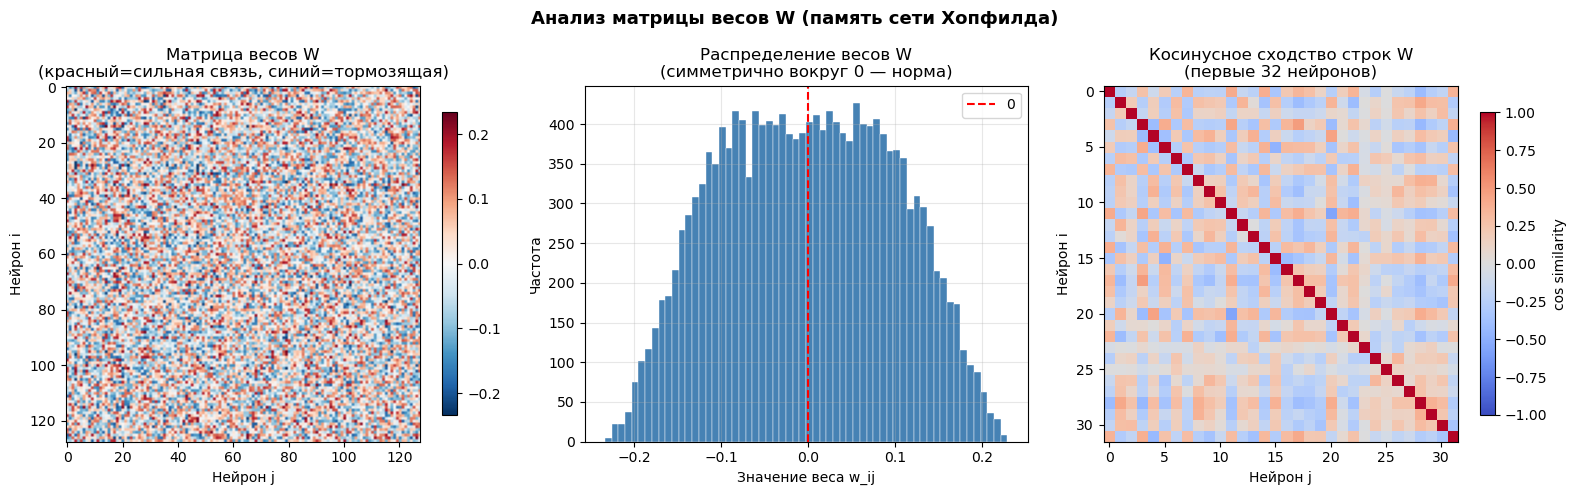


Расстояния между строками матрицы W (паттернами памяти):
  Минимальное : 1.1133  ← паттерны-близнецы (плохо!)
  Среднее     : 1.5735
  Максимальное: 2.1980  ← хорошо разделённые паттерны
  Std         : 0.1831

  Индекс разделения (min/mean): 0.708
  ✓ Паттерны хорошо разделены


In [23]:
# ── Извлекаем матрицу паттернов из обученного слоя Хопфилда ────────────────
hopfield_layer = base_model.get_layer("hopfield_classical")
W = hopfield_layer.W.numpy()  # [Ns, Ns] — симметричная матрица весов

print(f"Размер матрицы весов W: {W.shape}")
print(f"  min={W.min():.4f}  max={W.max():.4f}  mean={W.mean():.4f}  std={W.std():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Тепловая карта матрицы весов W ──────────────────────────────────────
im0 = axes[0].imshow(
    W, cmap="RdBu_r", aspect="auto", vmin=-np.abs(W).max(), vmax=np.abs(W).max()
)
axes[0].set_title("Матрица весов W\n(красный=сильная связь, синий=тормозящая)")
axes[0].set_xlabel("Нейрон j")
axes[0].set_ylabel("Нейрон i")
plt.colorbar(im0, ax=axes[0], shrink=0.85)

# ── 2. Гистограмма значений весов ─────────────────────────────────────────
axes[1].hist(W.flatten(), bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="--", label="0")
axes[1].set_title("Распределение весов W\n(симметрично вокруг 0 — норма)")
axes[1].set_xlabel("Значение веса w_ij")
axes[1].set_ylabel("Частота")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── 3. Матрица попарных косинусных расстояний между строками W ─────────────
# Каждая строка W — это «как нейрон i влияет на всех остальных»
# Косинусное сходство строк показывает: насколько похожи роли разных нейронов
W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-8)
cos_sim = W_norm @ W_norm.T  # [Ns, Ns]
# Берём только первые 32 нейрона для читаемости
n_show = min(32, Ns)
im2 = axes[2].imshow(
    cos_sim[:n_show, :n_show], cmap="coolwarm", aspect="auto", vmin=-1, vmax=1
)
axes[2].set_title(f"Косинусное сходство строк W\n(первые {n_show} нейронов)")
axes[2].set_xlabel("Нейрон j")
axes[2].set_ylabel("Нейрон i")
plt.colorbar(im2, ax=axes[2], shrink=0.85, label="cos similarity")

plt.suptitle(
    "Анализ матрицы весов W (память сети Хопфилда)", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── Статистика расстояний между строками W ─────────────────────────────────
from scipy.spatial.distance import pdist

row_distances = pdist(W, metric="euclidean")
print(f"\nРасстояния между строками матрицы W (паттернами памяти):")
print(f"  Минимальное : {row_distances.min():.4f}  ← паттерны-близнецы (плохо!)")
print(f"  Среднее     : {row_distances.mean():.4f}")
print(f"  Максимальное: {row_distances.max():.4f}  ← хорошо разделённые паттерны")
print(f"  Std         : {row_distances.std():.4f}")
separation_ratio = row_distances.min() / (row_distances.mean() + 1e-8)
print(f"\n  Индекс разделения (min/mean): {separation_ratio:.3f}")
if separation_ratio > 0.3:
    print("  ✓ Паттерны хорошо разделены")
elif separation_ratio > 0.1:
    print("  ⚠ Есть частичное перекрытие паттернов")
else:
    print("  ✗ Паттерны слипаются — память переполнена (переобучение!)")

## 6б. Конечность памяти Хопфилда

**Теоретическая ёмкость** классической сети Хопфилда:

$$P_{\max} \approx 0.138 \cdot N$$

где $N$ — число нейронов. Если запомнить больше — паттерны начинают перекрываться,
сеть «путает» воспоминания и выдаёт ложные аттракторы (spurious states).

- 🟢 — загружено меньше 14% от ёмкости. Все паттерны различимы.
- 🟡 — 14–25% ёмкости. Начинаются ошибки при сильном шуме.
- 🔴 — больше 25% ёмкости. Паттерны слипаются, возникают ложные воспоминания.

Параметры теста:
  N нейронов         = 100
  Теор. ёмкость P*   = 13 паттернов (13.0% от N)


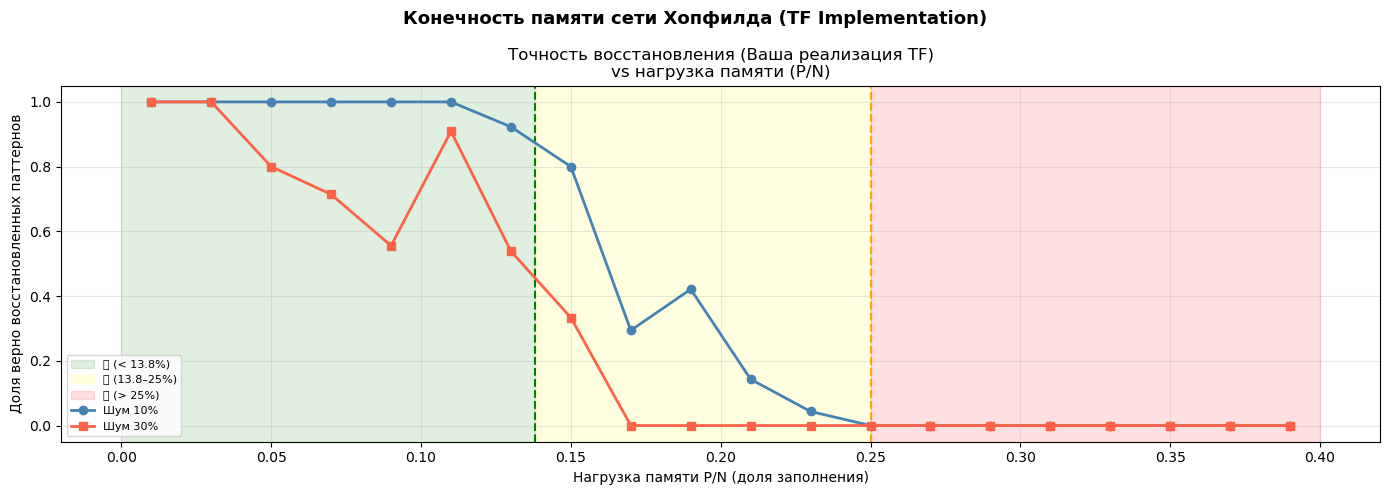

In [ ]:
# ── Параметры теста ─────────────────────────────────────────────────────────

N_demo = 100
P_capacity = int(0.138 * N_demo)
P_test_values = list(range(1, int(0.40 * N_demo), 2))
rng = np.random.default_rng(42)

print(f"Параметры теста:")
print(f"  N нейронов         = {N_demo}")
print(
    f"  Теор. ёмкость P*   = {P_capacity} паттернов ({P_capacity/N_demo*100:.1f}% от N)"
)

# ── Функция оценки точности с использованием вашего слоя ────────────────────


def calculate_accuracy(hopfield_layer, patterns_np, noise_level):
    """
    Тестирует слой на паттернах с шумом.
    """
    P = len(patterns_np)
    correct = 0

    for pat in patterns_np:
        # 1. Добавляем шум (NumPy)
        flip_mask = rng.random(N_demo) < noise_level
        noisy = pat.copy()
        noisy[flip_mask] *= -1

        # 2. Преобразуем в Tensor для слоя [batch, neurons]
        noisy_tf = tf.expand_dims(tf.constant(noisy, dtype=tf.float32), axis=0)

        # 3. Вызываем ваш слой (Recurrent Update)
        recalled_tf = hopfield_layer(noisy_tf)
        recalled_np = recalled_tf[0].numpy()

        # 4. Сравниваем (используем sign на всякий случай, хотя слой возвращает ±1)
        if np.array_equal(np.sign(recalled_np), pat):
            correct += 1

    return correct / P


# ── Основной цикл тестирования ──────────────────────────────────────────────

accuracies_low = []
accuracies_high = []

for P in P_test_values:
    # Генерируем паттерны
    patterns = rng.choice([-1, 1], size=(P, N_demo)).astype(float)
    patterns_tf = tf.constant(patterns, dtype=tf.float32)

    hopfield_net = ClassicalHopfieldLayer(num_neurons=N_demo)

    # 2. Записываем паттерны (Hebbian Learning)
    hopfield_net.store_patterns(patterns_tf)

    # 3. Тестируем точность
    acc_low = calculate_accuracy(hopfield_net, patterns, noise_level=0.10)
    acc_high = calculate_accuracy(hopfield_net, patterns, noise_level=0.30)

    accuracies_low.append(acc_low)
    accuracies_high.append(acc_high)

load_ratio = [p / N_demo for p in P_test_values]

# ── Графики ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(14, 5))

plt.axvspan(0, 0.138, alpha=0.12, color="green", label="🟢 (< 13.8%)")
plt.axvspan(0.138, 0.25, alpha=0.12, color="yellow", label="🟡 (13.8–25%)")
plt.axvspan(0.25, 0.40, alpha=0.12, color="red", label="🔴 (> 25%)")
plt.axvline(0.138, color="green", linewidth=1.5, linestyle="--")
plt.axvline(0.25, color="orange", linewidth=1.5, linestyle="--")

plt.plot(
    load_ratio, accuracies_low, "o-", color="steelblue", linewidth=2, label="Шум 10%"
)
plt.plot(
    load_ratio, accuracies_high, "s-", color="tomato", linewidth=2, label="Шум 30%"
)

plt.title("Точность восстановления (Ваша реализация TF)\nvs нагрузка памяти (P/N)")
plt.xlabel("Нагрузка памяти P/N (доля заполнения)")
plt.ylabel("Доля верно восстановленных паттернов")
plt.ylim(-0.05, 1.05)
plt.legend(fontsize=8, loc="lower left")
plt.grid(alpha=0.3)

plt.suptitle(
    "Конечность памяти сети Хопфилда (TF Implementation)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 7. Прогнозирование и визуализация результатов

RMSE (train): 111.60 USD
RMSE (test):  492.05 USD


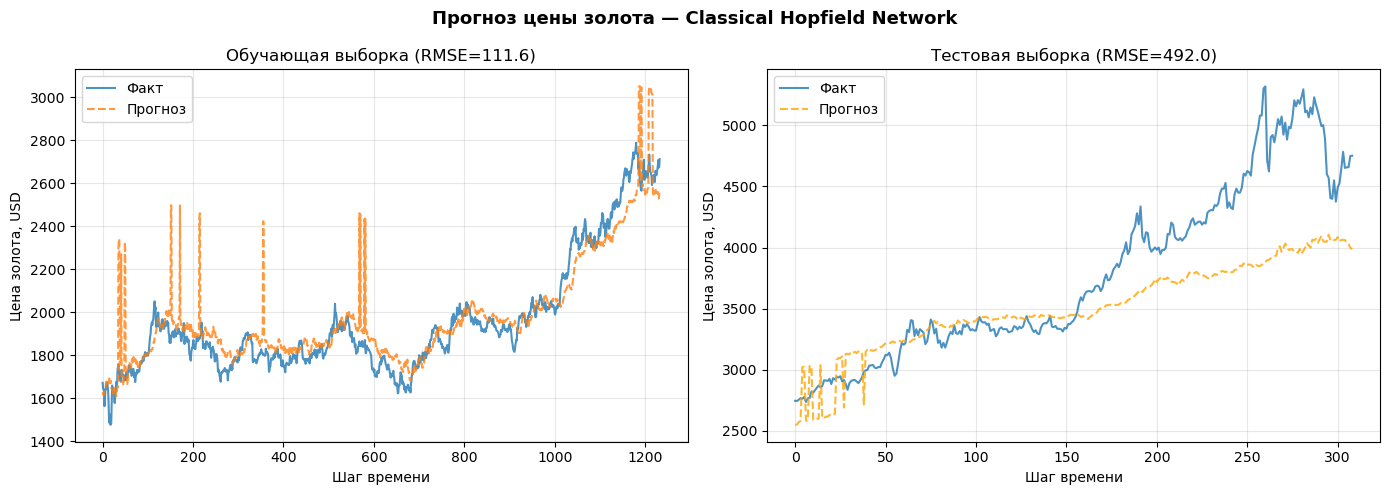

In [25]:
y_pred_train = base_model.predict(X_train, verbose=0).flatten()
y_pred_test = base_model.predict(X_test, verbose=0).flatten()


# Обратное масштабирование
def inverse(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


y_train_real = inverse(y_train)
y_test_real = inverse(y_test)
y_pred_train_real = inverse(y_pred_train)
y_pred_test_real = inverse(y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train_real, y_pred_train_real))
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
print(f"RMSE (train): {rmse_train:.2f} USD")
print(f"RMSE (test):  {rmse_test:.2f} USD")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_train_real, label="Факт", alpha=0.8)
axes[0].plot(y_pred_train_real, label="Прогноз", alpha=0.8, linestyle="--")
axes[0].set_title(f"Обучающая выборка (RMSE={rmse_train:.1f})")
axes[0].set_xlabel("Шаг времени")
axes[0].set_ylabel("Цена золота, USD")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(y_test_real, label="Факт", alpha=0.8)
axes[1].plot(
    y_pred_test_real, label="Прогноз", alpha=0.8, linestyle="--", color="orange"
)
axes[1].set_title(f"Тестовая выборка (RMSE={rmse_test:.1f})")
axes[1].set_xlabel("Шаг времени")
axes[1].set_ylabel("Цена золота, USD")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Прогноз цены золота — Classical Hopfield Network", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 8. Зависимость функции потерь от параметров M, D, L, Ns

По очереди варьируем **один параметр**, остальные фиксируются на базовых значениях.

In [26]:
def run_sweep(
    param_name,
    param_values,
    base_M=30,
    base_D=1,
    base_L=5,
    base_Ns=128,
    epochs=40,
    batch_size=32,
):
    """Запускает серию экспериментов, варьируя один параметр.

    Returns:
        dict: param_value → {'train_loss': [...], 'val_loss': [...],
                              'final_train': float, 'final_val': float}
    """
    results = {}
    for val in param_values:
        cur_M = val if param_name == "M" else base_M
        cur_D = val if param_name == "D" else base_D
        cur_L = val if param_name == "L" else base_L
        cur_Ns = val if param_name == "Ns" else base_Ns

        Xi, yi = build_dataset(data_scaled, cur_M, cur_D, cur_L)
        if len(Xi) < 50:
            print(f"  [{param_name}={val}] Недостаточно данных, пропуск")
            continue
        sp = int(len(Xi) * 0.8)
        Xtr, Xte = Xi[:sp], Xi[sp:]
        ytr, yte = yi[:sp], yi[sp:]

        with tf.device("/GPU:0" if gpus else "/CPU:0"):
            model = build_hopfield_model(Xtr.shape[1], Ns=cur_Ns)
            hist = train_model(
                model,
                Xtr,
                ytr,
                Xte,
                yte,
                epochs=epochs,
                batch_size=batch_size,
                early_stop=False,
                verbose=0,
            )

        tl = hist.history["loss"]
        vl = hist.history["val_loss"]
        results[val] = {
            "train_loss": tl,
            "val_loss": vl,
            "final_train": tl[-1],
            "final_val": vl[-1],
        }
        print(
            f"  [{param_name}={val:>4}] train_loss={tl[-1]:.5f}  val_loss={vl[-1]:.5f}"
        )
    return results


def plot_sweep_curves(results, param_name, title_suffix=""):
    """Строит кривые обучения и итоговый bar-chart для одного sweep."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cmap = plt.get_cmap("viridis", len(results))
    values = sorted(results.keys())

    for idx, v in enumerate(values):
        color = cmap(idx)
        axes[0].plot(
            results[v]["train_loss"],
            color=color,
            linestyle="--",
            alpha=0.7,
            linewidth=1,
        )
        axes[0].plot(
            results[v]["val_loss"],
            color=color,
            label=f"{param_name}={v}",
            linewidth=1.5,
        )

    axes[0].set_title(f"Кривые потерь при варьировании {param_name}{title_suffix}")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("MSE")
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(alpha=0.3)

    final_train = [results[v]["final_train"] for v in values]
    final_val = [results[v]["final_val"] for v in values]
    x_pos = np.arange(len(values))
    w = 0.35
    axes[1].bar(x_pos - w / 2, final_train, w, label="Train Loss", alpha=0.8)
    axes[1].bar(x_pos + w / 2, final_val, w, label="Val Loss", alpha=0.8)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(v) for v in values])
    axes[1].set_title(f"Итоговые потери vs {param_name}")
    axes[1].set_xlabel(param_name)
    axes[1].set_ylabel("MSE (финальная эпоха)")
    axes[1].legend()
    axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle(
        f"Влияние параметра {param_name} на функцию потерь",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

### 8.1 Варьирование M — ширины окна наблюдения

Sweep по M (D=1, L=5, Ns=128)


2026-04-09 11:47:48.713873: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:47:48.713928: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:47:49.350761: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 28 bytes spill stores, 28 bytes spill loads

2026-04-09 11:47:49.532349: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [M=   5] train_loss=0.00531  val_loss=0.07168


2026-04-09 11:48:00.746466: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:48:00.746524: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:48:01.471397: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 28 bytes spill stores, 28 bytes spill loads

2026-04-09 11:48:01.906579: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [M=  10] train_loss=0.00394  val_loss=0.24213


...

  [M=  20] train_loss=0.00028  val_loss=0.05118
  [M=  30] train_loss=0.00077  val_loss=0.02771


2026-04-09 11:48:34.513845: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:48:35.258352: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 16 bytes spill stores, 16 bytes spill loads

2026-04-09 11:48:35.281482: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 16 bytes spill stores, 16 bytes spill loads

2026-04-09 11:48:35.444144: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 416 byte

  [M=  50] train_loss=0.00170  val_loss=0.12682


2026-04-09 11:48:44.752482: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:48:45.332526: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 16 bytes spill stores, 16 bytes spill loads

2026-04-09 11:48:45.570909: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 240 bytes spill stores, 240 bytes spill loads



  [M=  70] train_loss=0.00053  val_loss=0.13489


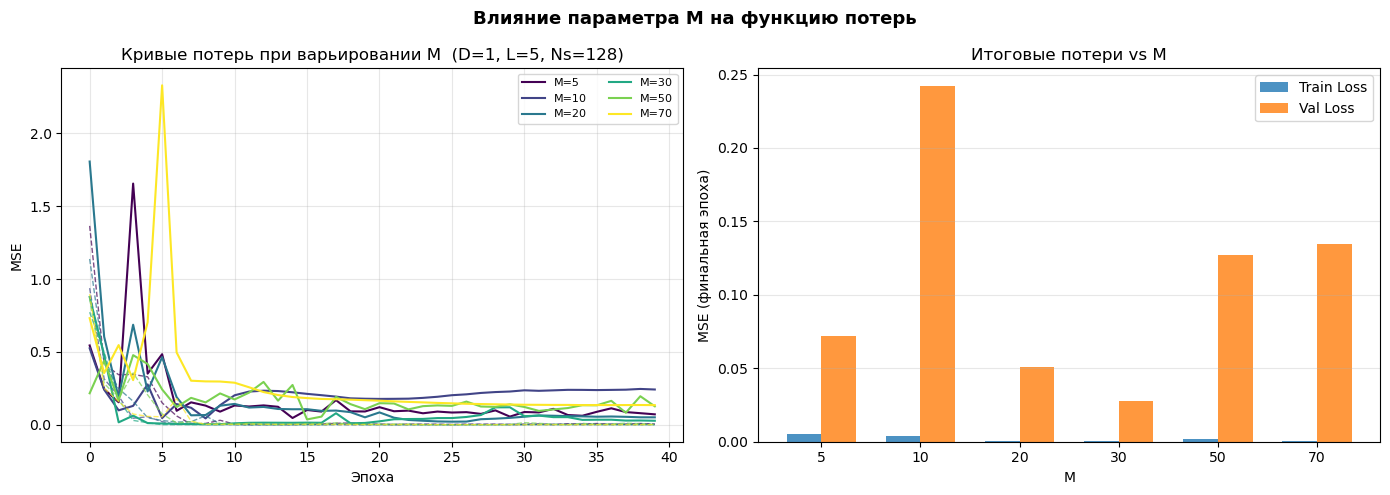

In [27]:
M_values = [5, 10, 20, 30, 50, 70]
print(f"Sweep по M (D={D}, L={L}, Ns={Ns})")
results_M = run_sweep("M", M_values, base_D=D, base_L=L, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_M, "M", f"  (D={D}, L={L}, Ns={Ns})")

### 8.2 Варьирование D — глубины задержек

Sweep по D (M=30, L=5, Ns=128)
  [D=   1] train_loss=0.00048  val_loss=0.03426
  [D=   2] train_loss=0.00033  val_loss=0.00864
  [D=   3] train_loss=0.00056  val_loss=0.05365
  [D=   5] train_loss=0.00059  val_loss=0.19825
  [D=   7] train_loss=0.00047  val_loss=0.15562
  [D=  10] train_loss=0.00101  val_loss=0.04020


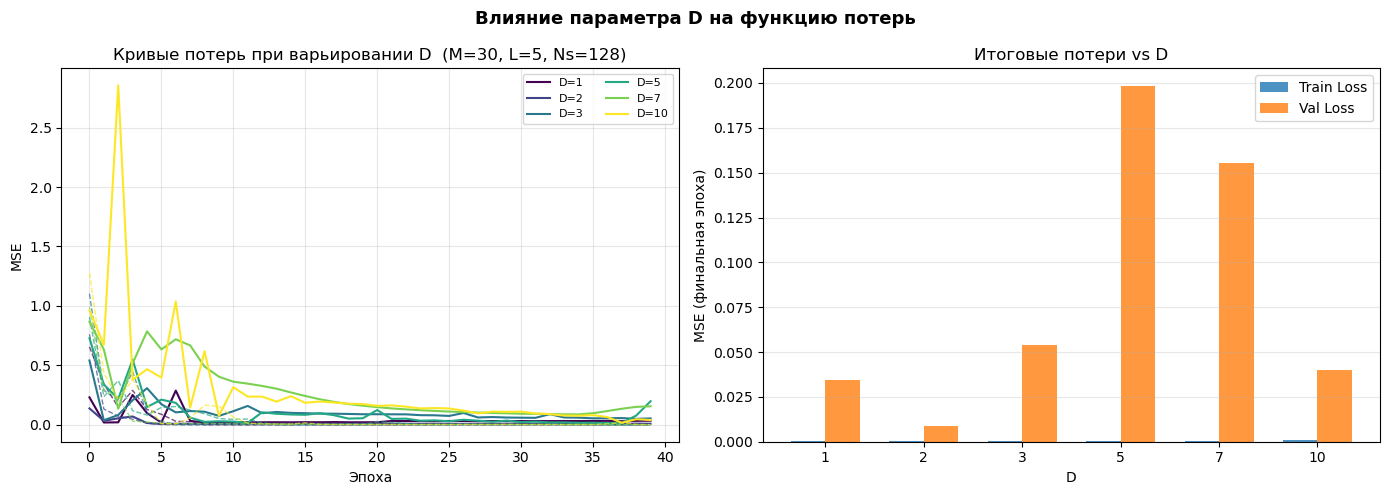

In [28]:
D_values = [1, 2, 3, 5, 7, 10]
print(f"Sweep по D (M={M}, L={L}, Ns={Ns})")
results_D = run_sweep("D", D_values, base_M=M, base_L=L, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_D, "D", f"  (M={M}, L={L}, Ns={Ns})")

### 8.3 Варьирование L — горизонта прогнозирования

Sweep по L (M=30, D=1, Ns=128)


2026-04-09 11:50:07.694568: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:50:07.694624: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:50:07.694638: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:50:08.369124: I external/l

  [L=   1] train_loss=0.04833  val_loss=0.18397


2026-04-09 11:50:22.114620: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:50:22.114674: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:50:22.114688: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:50:22.826699: I external/l

  [L=   3] train_loss=0.00227  val_loss=0.12036
  [L=   5] train_loss=0.00461  val_loss=0.25652
  [L=  10] train_loss=0.00196  val_loss=0.05269
  [L=  15] train_loss=0.00056  val_loss=0.16444


2026-04-09 11:51:07.870242: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:51:07.870296: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:51:08.870847: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 8 bytes spill stores, 8 bytes spill loads

2026-04-09 11:51:08.911419: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

  [L=  20] train_loss=0.00395  val_loss=0.00783


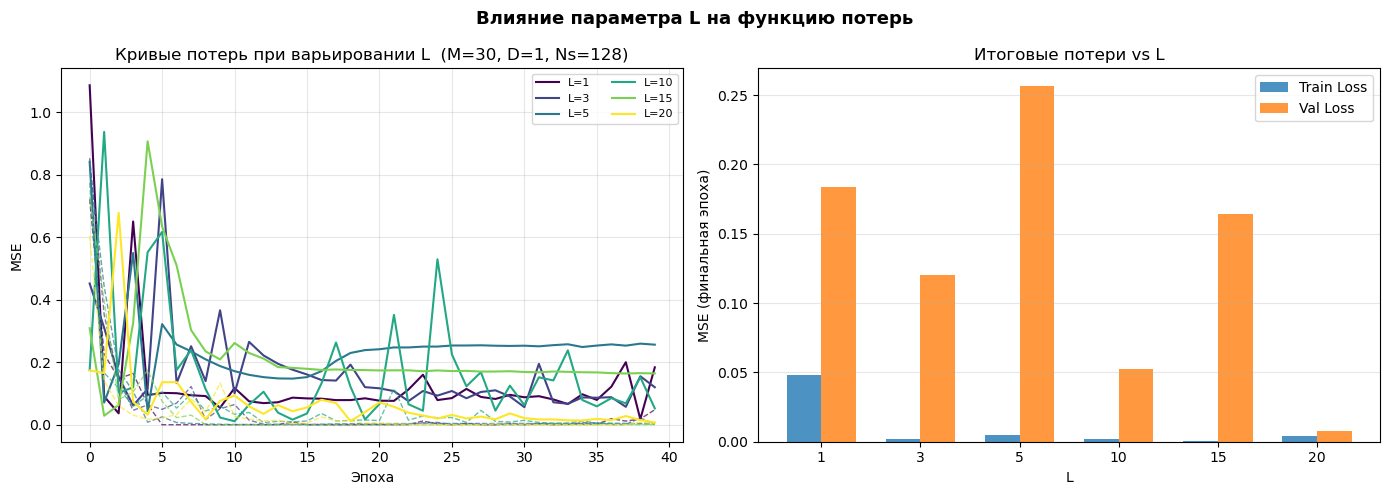

In [29]:
L_values = [1, 3, 5, 10, 15, 20]
print(f"Sweep по L (M={M}, D={D}, Ns={Ns})")
results_L = run_sweep("L", L_values, base_M=M, base_D=D, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_L, "L", f"  (M={M}, D={D}, Ns={Ns})")

### 8.4 Варьирование Ns — числа нейронов в слое Хопфилда

Sweep по Ns (M=30, D=1, L=5)
  [Ns=  16] train_loss=0.00093  val_loss=0.09025
  [Ns=  32] train_loss=0.00464  val_loss=0.25680


2026-04-09 11:51:38.731291: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 16 bytes spill stores, 16 bytes spill loads

2026-04-09 11:51:40.670330: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 16 bytes spill stores, 16 bytes spill loads



  [Ns=  64] train_loss=0.00176  val_loss=0.12314
  [Ns= 128] train_loss=0.00068  val_loss=0.00347


2026-04-09 11:51:57.347497: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:51:57.347555: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:51:57.347572: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:51:57.347593: I external/l

  [Ns= 256] train_loss=0.00037  val_loss=0.04344


...

  [Ns=1024] train_loss=0.00335  val_loss=0.23257


2026-04-09 11:52:45.818436: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:52:46.429179: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 4 bytes spill stores, 4 bytes spill loads

2026-04-09 11:52:46.838866: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_139', 332 bytes spill stores, 292 bytes spill loads

2026-04-09 11:52:47.160932: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 56 bytes

  [Ns=2048] train_loss=0.01337  val_loss=0.66135


2026-04-09 11:53:02.052201: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-09 11:53:02.479778: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 4 bytes spill stores, 4 bytes spill loads

2026-04-09 11:53:03.109839: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 4 bytes spill stores, 4 bytes spill loads

2026-04-09 11:53:03.217710: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_139', 332 bytes sp

  [Ns=4096] train_loss=0.00097  val_loss=0.02773


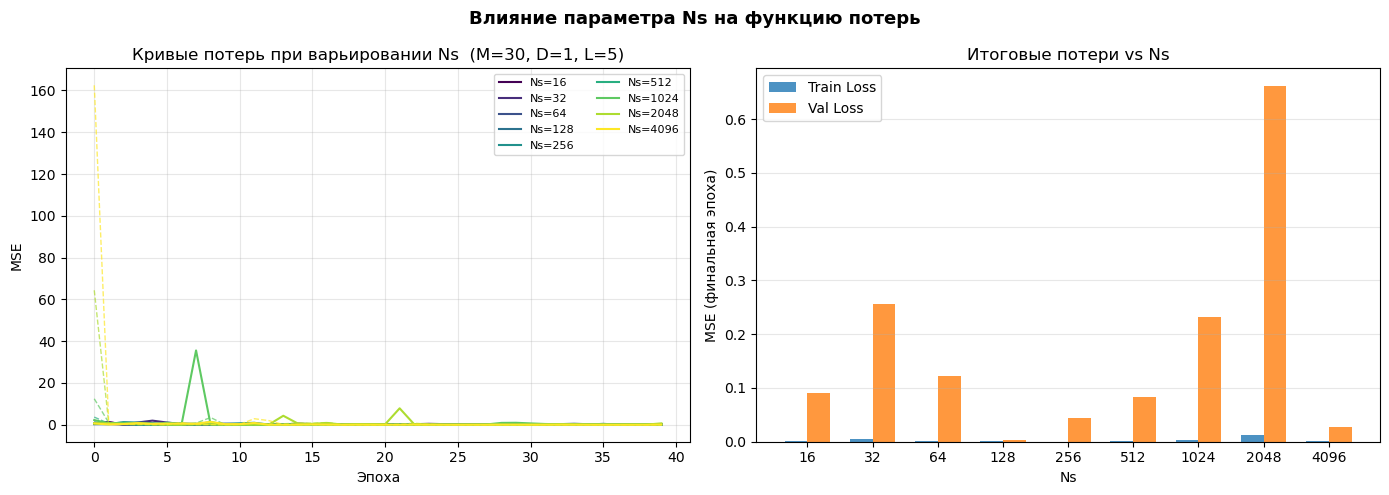

In [30]:
Ns_values = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
print(f"Sweep по Ns (M={M}, D={D}, L={L})")
results_Ns = run_sweep("Ns", Ns_values, base_M=M, base_D=D, base_L=L, epochs=40)
plot_sweep_curves(results_Ns, "Ns", f"  (M={M}, D={D}, L={L})")

## 9. Демонстрация переобучения

Чтобы вызвать переобучение, используем:
- **Очень большой Ns** (много параметров, много «паттернов памяти»)
- **Маленький объём обучающих данных** (M=5, малое окно → мало признаков и образцов)
- **Отсутствие ранней остановки** и большое число эпох

Параметры для демонстрации переобучения: M=10, Ns=1024, epochs=200
Обучающая выборка: 1249 образцов


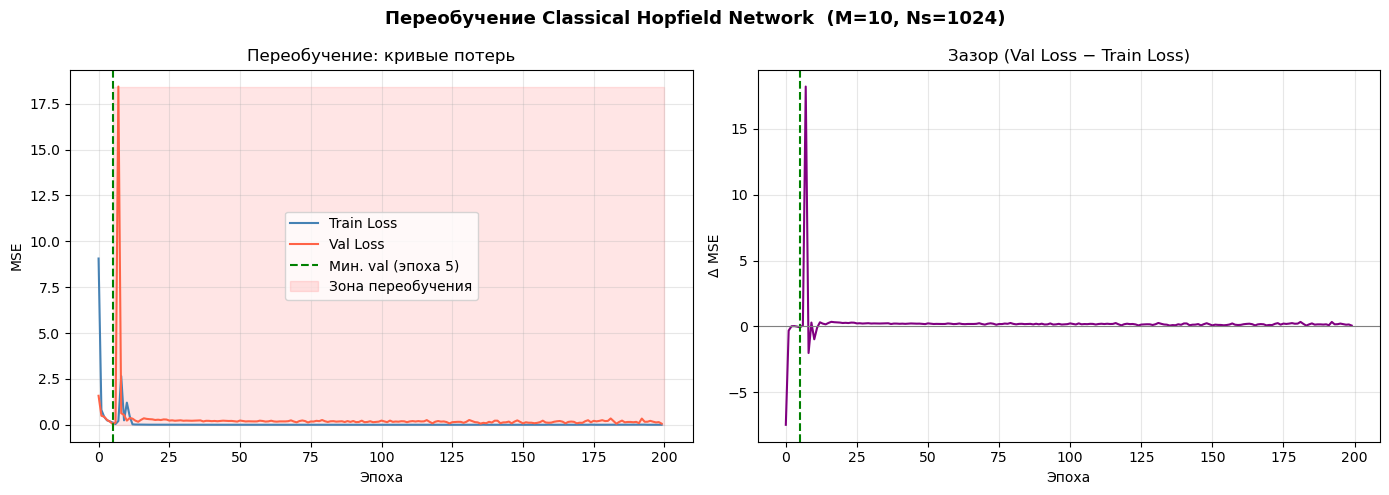


Минимальный val_loss на эпохе 5: 0.04347
Финальный train_loss: 0.00266  |  Финальный val_loss: 0.06454
Зазор переобучения: 0.06188


In [31]:
# Настройки, провоцирующие переобучение
M_of = 10  # Маленькое окно
Ns_of = 1024  # Гигантский скрытый слой
EPC_OF = 200  # Много эпох, без ранней остановки

X_of, y_of = build_dataset(data_scaled, M_of, D=1, L=L)
sp_of = int(len(X_of) * 0.8)
X_tr_of, X_te_of = X_of[:sp_of], X_of[sp_of:]
y_tr_of, y_te_of = y_of[:sp_of], y_of[sp_of:]

print(f"Параметры для демонстрации переобучения: M={M_of}, Ns={Ns_of}, epochs={EPC_OF}")
print(f"Обучающая выборка: {len(X_tr_of)} образцов")

with tf.device("/GPU:0" if gpus else "/CPU:0"):
    overfit_model = build_hopfield_model(X_tr_of.shape[1], Ns=Ns_of)
    overfit_history = train_model(
        overfit_model,
        X_tr_of,
        y_tr_of,
        X_te_of,
        y_te_of,
        epochs=EPC_OF,
        batch_size=BATCH,
        early_stop=False,
        verbose=0,
    )

tl_of = overfit_history.history["loss"]
vl_of = overfit_history.history["val_loss"]

# ── Поиск точки начала переобучения ────────────────────────────────────────
best_val_epoch = int(np.argmin(vl_of))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Кривые потерь
axes[0].plot(tl_of, label="Train Loss", color="steelblue")
axes[0].plot(vl_of, label="Val Loss", color="tomato")
axes[0].axvline(
    best_val_epoch,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"Мин. val (эпоха {best_val_epoch})",
)
axes[0].fill_betweenx(
    [0, max(vl_of)],
    best_val_epoch,
    EPC_OF,
    alpha=0.1,
    color="red",
    label="Зона переобучения",
)
axes[0].set_title("Переобучение: кривые потерь")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Зазор train/val по эпохам
gap = np.array(vl_of) - np.array(tl_of)
axes[1].plot(gap, color="purple")
axes[1].axvline(best_val_epoch, color="green", linestyle="--", linewidth=1.5)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("Зазор (Val Loss − Train Loss)")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Δ MSE")
axes[1].grid(alpha=0.3)

plt.suptitle(
    f"Переобучение Classical Hopfield Network  (M={M_of}, Ns={Ns_of})",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"\nМинимальный val_loss на эпохе {best_val_epoch}: {min(vl_of):.5f}")
print(f"Финальный train_loss: {tl_of[-1]:.5f}  |  Финальный val_loss: {vl_of[-1]:.5f}")
print(f"Зазор переобучения: {vl_of[-1] - tl_of[-1]:.5f}")

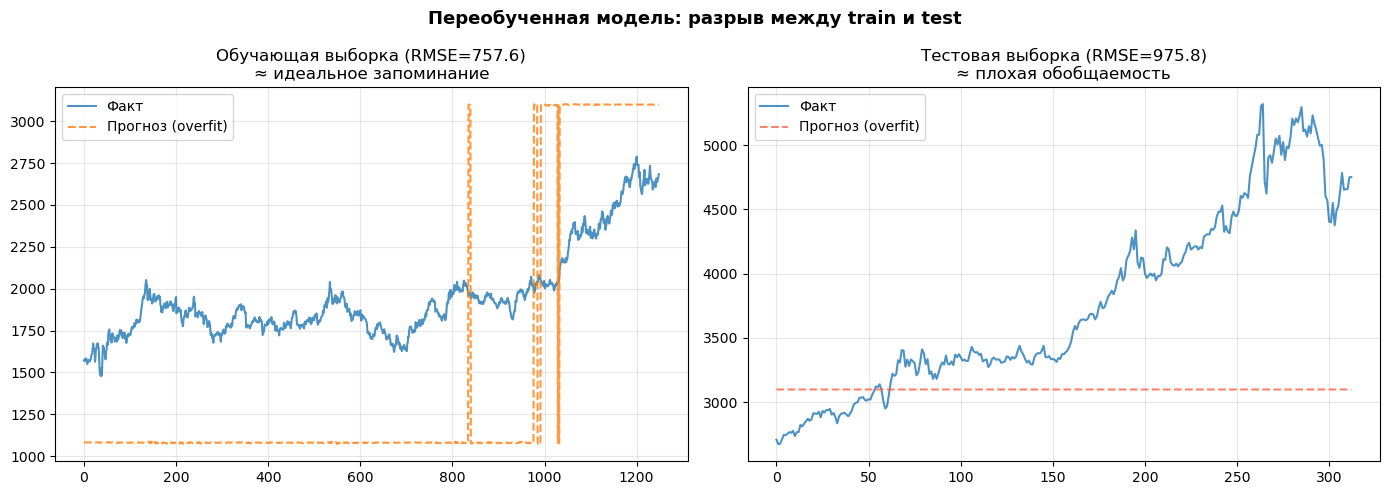

In [32]:
# Сравнение прогнозов: переобученная vs нормальная модель
y_pred_of_train = overfit_model.predict(X_tr_of, verbose=0).flatten()
y_pred_of_test = overfit_model.predict(X_te_of, verbose=0).flatten()


def inv(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# На train — отличное совпадение (запомнила данные)
axes[0].plot(inv(y_tr_of), label="Факт", alpha=0.8)
axes[0].plot(inv(y_pred_of_train), label="Прогноз (overfit)", linestyle="--", alpha=0.8)
rmse_tr = np.sqrt(mean_squared_error(inv(y_tr_of), inv(y_pred_of_train)))
axes[0].set_title(f"Обучающая выборка (RMSE={rmse_tr:.1f})\n≈ идеальное запоминание")
axes[0].legend()
axes[0].grid(alpha=0.3)

# На test — плохое качество
axes[1].plot(inv(y_te_of), label="Факт", alpha=0.8)
axes[1].plot(
    inv(y_pred_of_test),
    label="Прогноз (overfit)",
    linestyle="--",
    alpha=0.8,
    color="tomato",
)
rmse_te = np.sqrt(mean_squared_error(inv(y_te_of), inv(y_pred_of_test)))
axes[1].set_title(f"Тестовая выборка (RMSE={rmse_te:.1f})\n≈ плохая обобщаемость")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Переобученная модель: разрыв между train и test", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()